# PF-5039: Análisis de Imágenes Médicas y Biológicas
## Semana 02 — Tarea Autónoma Calificada (1 a 1.5 Horas)
### Implementación Manual de HE y Caso de Estudio Biomédico con CLAHE

**Estudiante:** ____________________________________ **Carné:** __________________

---
### Instrucciones de Entrega:
- Complete los dos ejercicios programando las celdas marcadas con `TODO`.
- Debe subir su cuaderno resuelto en formato `.ipynb` antes de la fecha límite establecida.
- **Rigor:** En la Parte A no está permitido el uso de funciones de alto nivel de OpenCV (como `cv2.equalizeHist`). Debe construir el algoritmo desde cero utilizando únicamente álgebra vectorial de NumPy.

**Referencias:**
1. González, R. C., & Woods, R. E. (2018). *Digital Image Processing* (4th ed.). Pearson. Cap. 3.
2. Zuiderveld, K. (1994). Contrast Limited Adaptive Histogram Equalization. *Graphics Gems IV*, 474–485.

---
### Ejercicio 1 (50%): Implementación Manual de Ecualización de Histograma (HE) en NumPy

**Fundamento Teórico:**
La Ecualización de Histograma busca transformar la variable aleatoria de intensidad $r \in [0, L-1]$ mediante su Función de Distribución Acumulada (CDF):
$$s_k = T(r_k) = \text{round}\left( (L-1) \sum_{j=0}^{k} p(r_j) \right) = \text{round}\left( \frac{L-1}{M \cdot N} \sum_{j=0}^{k} h(r_j) \right)$$

**Instrucciones:**
1. Cargue la imagen histológica `histopatologia_ihc.png` en escala de grises.
2. Implemente la función `ecualizacion_manual_numpy(img)` **únicamente con NumPy** (sin OpenCV):
   - Calcule el histograma de conteo $h(r_k)$ para los 256 niveles.
   - Calcule la CDF acumulada discreta con `np.cumsum`.
   - Escale la CDF al rango $[0, 255]$, redondee y convierta a `uint8`.
   - Utilice la CDF resultante como una Look-Up Table de indexación sobre la matriz de la imagen: `img_eq = cdf_escalada[img]`.
3. Valide su implementación contra la función nativa `cv2.equalizeHist(img)` calculando el **PSNR** ($> 45\text{ dB}$) y el Error Cuadrático Medio (**MSE**).

Dimensiones: (512, 512)
Tipo de datos: uint8
MSE: 0.000000
PSNR: infinito (las imágenes son idénticas)
Validación exitosa: PSNR mayor que 45 dB.


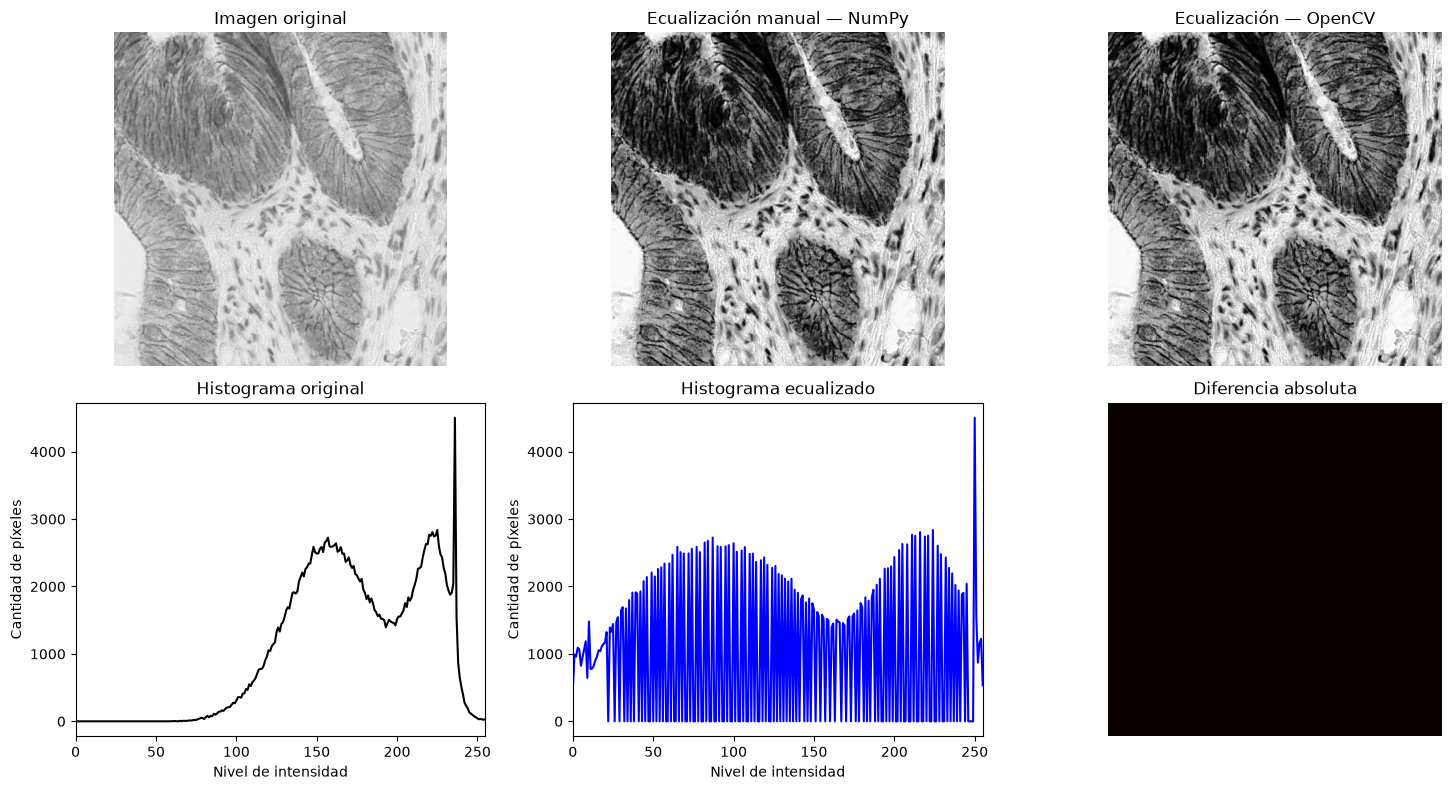

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def ecualizacion_manual_numpy(img):
    """
    Ecualiza una imagen en escala de grises utilizando únicamente NumPy.

    Parámetros
    ----------
    img : np.ndarray
        Imagen de entrada en escala de grises y formato uint8.

    Retorna
    -------
    img_eq : np.ndarray
        Imagen ecualizada.
    histograma : np.ndarray
        Histograma original de 256 niveles.
    cdf_escalada : np.ndarray
        Tabla de transformación o Look-Up Table.
    """

    # 1. Calcular el histograma de conteo para los 256 niveles
    histograma = np.bincount(img.ravel(), minlength=256)

    # 2. Calcular la función de distribución acumulada
    cdf = np.cumsum(histograma)

    # Buscar el primer valor no nulo de la CDF
    valores_no_nulos = cdf[cdf > 0]

    # Caso especial: imagen vacía o sin información
    if valores_no_nulos.size == 0:
        return img.copy(), histograma, np.zeros(256, dtype=np.uint8)

    cdf_min = valores_no_nulos[0]
    total_pixeles = img.size

    # Caso especial: imagen con un solo nivel de intensidad
    if total_pixeles == cdf_min:
        cdf_escalada = np.zeros(256, dtype=np.uint8)
        img_eq = img.copy()
        return img_eq, histograma, cdf_escalada

    # 3. Escalar la CDF al rango [0, 255]
    cdf_escalada = (
        (cdf.astype(np.float64) - cdf_min)
        / (total_pixeles - cdf_min)
        * 255
    )

    # Evitar valores negativos en niveles no presentes
    cdf_escalada = np.clip(cdf_escalada, 0, 255)

    # Redondear y convertir a uint8
    cdf_escalada = np.round(cdf_escalada).astype(np.uint8)

    # 4. Aplicar la CDF como Look-Up Table
    img_eq = cdf_escalada[img]

    return img_eq, histograma, cdf_escalada


def calcular_mse(img1, img2):
    """Calcula el Error Cuadrático Medio entre dos imágenes."""
    diferencia = img1.astype(np.float64) - img2.astype(np.float64)
    return np.mean(diferencia ** 2)


def calcular_psnr(img1, img2):
    """Calcula el PSNR entre dos imágenes de 8 bits."""
    mse = calcular_mse(img1, img2)

    if mse == 0:
        return float("inf")

    return 10 * np.log10((255 ** 2) / mse)


# ---------------------------------------------------------
# Carga de la imagen
# ---------------------------------------------------------

ruta_imagen = r"C:\Users\Docente\Desktop\curso analisis imagenes\analisis-imagenes\tareas\tarea1\imagenes\histopatologia_ihc_canal.png"

# Cargar directamente en escala de grises
img = cv2.imread(ruta_imagen, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(
        f"No se pudo cargar la imagen: {ruta_imagen}. "
        "Verifique que esté en la misma carpeta que el programa."
    )

print("Dimensiones:", img.shape)
print("Tipo de datos:", img.dtype)


# ---------------------------------------------------------
# Ecualización manual con NumPy
# ---------------------------------------------------------

img_eq_manual, histograma, cdf_escalada = (
    ecualizacion_manual_numpy(img)
)


# ---------------------------------------------------------
# Ecualización nativa con OpenCV
# ---------------------------------------------------------

img_eq_opencv = cv2.equalizeHist(img)


# ---------------------------------------------------------
# Validación
# ---------------------------------------------------------

mse = calcular_mse(img_eq_manual, img_eq_opencv)
psnr = calcular_psnr(img_eq_manual, img_eq_opencv)

print(f"MSE: {mse:.6f}")

if np.isinf(psnr):
    print("PSNR: infinito (las imágenes son idénticas)")
else:
    print(f"PSNR: {psnr:.2f} dB")

if psnr > 45:
    print("Validación exitosa: PSNR mayor que 45 dB.")
else:
    print("Validación no superada: PSNR menor o igual que 45 dB.")


# ---------------------------------------------------------
# Visualización de resultados
# ---------------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Imagen original")
axes[0, 0].axis("off")

axes[0, 1].imshow(img_eq_manual, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title("Ecualización manual — NumPy")
axes[0, 1].axis("off")

axes[0, 2].imshow(img_eq_opencv, cmap="gray", vmin=0, vmax=255)
axes[0, 2].set_title("Ecualización — OpenCV")
axes[0, 2].axis("off")

axes[1, 0].plot(histograma, color="black")
axes[1, 0].set_title("Histograma original")
axes[1, 0].set_xlabel("Nivel de intensidad")
axes[1, 0].set_ylabel("Cantidad de píxeles")
axes[1, 0].set_xlim(0, 255)

histograma_manual = np.bincount(
    img_eq_manual.ravel(),
    minlength=256
)

axes[1, 1].plot(histograma_manual, color="blue")
axes[1, 1].set_title("Histograma ecualizado")
axes[1, 1].set_xlabel("Nivel de intensidad")
axes[1, 1].set_ylabel("Cantidad de píxeles")
axes[1, 1].set_xlim(0, 255)

# Diferencia absoluta entre ambos resultados
diferencia = np.abs(
    img_eq_manual.astype(np.int16)
    - img_eq_opencv.astype(np.int16)
)

axes[1, 2].imshow(diferencia, cmap="hot")
axes[1, 2].set_title("Diferencia absoluta")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Diferencia numérica entre ambos resultados
diferencia = np.abs(
    img_eq_manual.astype(np.int16)
    - img_eq_opencv.astype(np.int16)
)

mse = np.mean(
    (
        img_eq_manual.astype(np.float64)
        - img_eq_opencv.astype(np.float64)
    ) ** 2
)

if mse == 0:
    psnr = float("inf")
else:
    psnr = 10 * np.log10((255 ** 2) / mse)

print(f"MSE: {mse:.6f}")
print(f"PSNR: {psnr} dB")
print(f"Diferencia máxima: {diferencia.max()}")
print(f"Píxeles diferentes: {np.count_nonzero(diferencia)}")

: 

: 

In [ ]:
import os

print("Carpeta actual:")
print(os.getcwd())

print("\nArchivos disponibles:")
print(os.listdir())

Carpeta actual:
c:\Users\Docente\Desktop\curso analisis imagenes\analisis-imagenes\tareas\tarea1

Archivos disponibles:
['03_Tarea.ipynb', 'imagenes', 'tarea1.ipynb', 'tarea1Carolina.ipynb', 'tarea1Emily.ipynb']


: 

: 

: 

: 

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import mean_squared_error as mse

# Función auxiliar de carga compatible con rutas con acentos en Windows
def leer_imagen(ruta, flags=cv2.IMREAD_GRAYSCALE):
    img = cv2.imread(ruta, flags)
    if img is None and os.path.exists(ruta):
        img = cv2.imdecode(np.fromfile(ruta, dtype=np.uint8), flags)
    return img

# 1. Cargar imagen de prueba
img_ihc = leer_imagen('../../Imagenes_Ejemplo/histopatologia_ihc.png')
assert img_ihc is not None, "Error al cargar histopatologia_ihc.png"
print(f"Imagen cargada: {img_ihc.shape}, dtype={img_ihc.dtype}")

def ecualizacion_manual_numpy(img):
    """
    Implementación manual de Ecualización Global de Histograma (HE) con NumPy.
    Args:
        img (np.ndarray): Imagen en escala de grises (uint8).
    Returns:
        np.ndarray: Imagen ecualizada (uint8).
    """
    # ==========================================================================
    # TODO: Implemente el cálculo de la CDF y el mapeo Look-Up Table con NumPy
    # ==========================================================================
    # 1. hist, _ = np.histogram(img.ravel(), bins=256, range=[0, 256])
    # 2. cdf = np.cumsum(hist)
    # 3. cdf_min = cdf[cdf > 0][0] if len(cdf[cdf > 0]) > 0 else 0
    # 4. total_pixels = img.size
    # 5. cdf_lut = np.round(((cdf - cdf_min) / (total_pixels - cdf_min)) * 255.0).astype(np.uint8)
    # 6. return cdf_lut[img]
    return img.copy()  # <-- Reemplazar por su implementación

# 2. Ejecutar implementación manual vs OpenCV
img_manual = ecualizacion_manual_numpy(img_ihc)
img_opencv = cv2.equalizeHist(img_ihc)

# 3. Validación cuantitativa
val_mse = mse(img_opencv, img_manual)
val_psnr = psnr(img_opencv, img_manual, data_range=255)

print(f"--- Validación de Concordancia con OpenCV ---")
print(f"Error Cuadrático Medio (MSE): {val_mse:.4e}")
print(f"PSNR:                          {val_psnr:.2f} dB")

# 4. Visualización
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_ihc, cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(img_manual, cmap='gray'); axes[1].set_title('Implementación Manual (NumPy)'); axes[1].axis('off')
axes[2].imshow(np.abs(img_opencv.astype(int) - img_manual.astype(int)), cmap='hot')
axes[2].set_title(f'Diferencia Absoluta (MSE={val_mse:.2f})'); axes[2].axis('off')
plt.tight_layout()
plt.show()

: 

: 

: 

: 

---
### Ejercicio 2 (50%): Análisis de Hiperparámetros de CLAHE y Evaluación de Calidad en Bioimágenes

**Contexto Biomédico:** En imágenes histológicas o radiológicas, seleccionar inadecuadamente los hiperparámetros de CLAHE puede generar dos problemas:
- **`clipLimit` muy alto:** Pierde la restricción de recorte y converge hacia AHE convencional, amplificando el ruido de fondo.
- **`tileGridSize` muy pequeño:** Genera bloques diminutos con discontinuidades o texturas artificiales.

**Instrucciones:**
1. Aplique CLAHE variando sistemáticamente el límite de recorte `clipLimit` $\in [1.0, 2.0, 4.0, 8.0]$ manteniendo `tileGridSize=(8, 8)`.
2. Calcule la **Entropía de Shannon ($H$)** y la **Desviación Estándar ($\\sigma$) del contraste** para cada configuración.
3. Grafique la evolución de la métrica en función del `clipLimit`.
4. Redacte su **Conclusión Crítica (mínimo 5 oraciones)** en la celda final.

In [ ]:
# 1. Definir rango de hiperparámetros a evaluar
clip_limits = [1.0, 2.0, 4.0, 8.0, 16.0]
entropias = []
contrastes_std = []
resultados_clahe = []

def entropia_shannon(im):
    h, _ = np.histogram(im.ravel(), bins=256, range=[0, 256])
    pk = h / h.sum()
    pk = pk[pk > 0]
    return -np.sum(pk * np.log2(pk))

# ==========================================================================
# TODO: Bucle de evaluación de CLAHE variando clipLimit
# ==========================================================================
for clip in clip_limits:
    # clahe_obj = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8, 8))
    # out = clahe_obj.apply(img_ihc)
    # entropias.append(entropia_shannon(out))
    # contrastes_std.append(float(np.std(out)))
    # resultados_clahe.append(out)
    pass

# 2. Graficar métricas cuantitativas
plt.figure(figsize=(10, 4.5))
plt.subplot(1, 2, 1)
if len(entropias) > 0:
    plt.plot(clip_limits, entropias, 'o-', color='#1F4E79', lw=2)
plt.xlabel('Clip Limit')
plt.ylabel('Entropía H (bits/px)')
plt.title('Entropía de Shannon vs Clip Limit', fontweight='bold')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
if len(contrastes_std) > 0:
    plt.plot(clip_limits, contrastes_std, 's-', color='#C00000', lw=2)
plt.xlabel('Clip Limit')
plt.ylabel('Desviación Estándar (Contraste Global)')
plt.title('Dispersión de Contraste vs Clip Limit', fontweight='bold')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

: 

: 

: 

: 

---
### Conclusión Crítica:
> **(Redacte aquí su análisis crítico — mínimo 5 oraciones)**
>
> 1. ¿Cómo influye el aumento del `clipLimit` sobre la entropía y el ruido perceptible en las zonas de fondo?
> 2. ¿Por qué la ecualización global (HE) es desaconsejada frente a CLAHE en tinciones histológicas e imágenes radiológicas?
> 3. ¿Cuál considera que es el punto de operación óptimo para esta imagen y qué criterios diagnósticos respaldan su elección?